<div style="background-color: #0054A6; padding: 0px; border-radius: 0px; border: 0px solid #add8e6;"></div>

<table style="width: 100%; border: none; border-collapse: collapse; background-color: white; padding: 0px; border-radius: 0px;">
  <tr style="border: none;">
    <td style="width: 33%; border: none; text-align: left;">
        <img src="Elemen Grafis TJ 2-01.png" width="300">
    </td>
    <td style="width: 33%; border: none; text-align: center;">
        <img src="Busway putih.png" width="400">
    </td>
    <td style="width: 33%; border: none; text-align: right;">
        <img src="Elemen Grafis TJ Curve-01.png" width="300">
    </td>
  </tr>
</table>

<div style="background-color: #f0f8ff; padding: 0px; border-radius: 0px; border: 0px solid #add8e6;">

# <span style="color:#004B8D;"><center> Penjadwalan Dinamis Armada Transjakarta Berdasarkan Kepadatan Penumpang</center></span>
<div align="center"><span style="color:grey">Mengatasi Kesenjangan Beban Penumpang dan Efisiensi Armada pada Koridor Sibuk

<small>Capstone Project Modul 2 Didiek Arifman</small>
</span>
</div>
</div>

## <span style="color:lightblue">1. Latar Belakang</span>

<span style="color:lightblue">Transjakarta merupakan sistem transportasi BRT utama di Jakarta yang melayani jutaan penumpang setiap harinya. Namun, efisiensi operasional seringkali terhambat oleh distribusi beban penumpang yang tidak merata antar waktu dan koridor. Terdapat jam-jam tertentu di mana armada sangat padat, sementara di waktu lain bus beroperasi dengan kapasitas yang sangat rendah. Sebagai contoh pada jam sibuk, distribusi penumpang yang terkonsentrasi di koridor utama (seperti koridor 1 atau 9) membuat bus tertahan lebih lama di halte pada saat proses naik dan turunnya penumpang yang pada akhirnya mengganggu jadwal kedatangan bus berikutnya. 
Masalah tidak efisiensi operasional juga memberikan dampak langsung terhadap efisiensi anggaran, meskipun Transjakarta mencatatkan efisiensi subsidi per penumpang yang turun sebesar 14% pada tahun 2025, distribusi yang tidak merata tetap menjadi tantangan besar bagi manajemen anggaran dikarenakan Transjakarta tetap mengoperasikan bus dengan kapasitas penuh pada jam non sibuk demi menjaga standar pelayanan. </span>

### <span style="color:lightblue">1.1. Pernyataan Masalah</span>

<span style="color:lightblue">Mengoptimalkan penggunaan armada Transjakarta dalam meningkatkan kenyamanan penumpang melalui penjadwalan yang dinamis dengan menganalisis:

<span style="color:lightblue">1. Bagaimana pola kepadatan penumpang pada koridor utama di jam sibuk vs jam sepi?

<span style="color:lightblue">2. Apakah rute pengumpan (*Feeder*) sudah tersinkronisasi dengan baik dengan rute utama?

<span style="color:lightblue">3. Bagaimana perbedaan karakteristik kebutuhan armada antara hari kerja (*weekday*) dan hari libur (*weekend*)?

<span style="color:lightblue">4. Kapan dan di mana intervensi jadwal perlu dilakukan untuk menyeimbangkan antara biaya operasional dan kualitas layanan?
</span>

## <span style="color:lightblue">2. Data</span>

### <span style="color:lightblue">2.1. Data Understanding</span>

<span style="color:lightblue">Langkah pertama yang harus kita lakukan dalam proses ini adalah dengan mengenal dataset yang kita dapatkan. Tanpa memahami dataset awal, kita beresiko menghilangkan data yang sebenarnya penting untuk kita analisis maupun kita gagal mendeteksi anomali yang ada dalam dataset awal kita sehingga hasil analisa yang akan kita dapatkan nantinya tidak valid atau tidak dapat diproses.</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap # Library tambahan untuk gradasi

import warnings
warnings.filterwarnings("ignore")

<span style="color:lightblue">Memuat dataset Transjakarta.csv</span>

In [2]:
df = pd.read_csv('Transjakarta.csv')
df

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37895,ZWEC949B8Q87QG,4685818286724028395,brizzi,Kamila Mahendra,F,2004,6B,Ragunan - MH Thamrin via Semanggi,1.0,P00261,...,106.82309,2,2023-04-21 18:18:37,P00228,SMK 57,-6.290967,106.82365,13.0,2023-04-21 19:55:49,3500.0
37896,YHHK837P6Y95GN,6502902290603767,dki,Titi Siregar,M,1974,9N,Pinang Ranti - Pramuka,1.0,P00064,...,106.88116,1,2023-04-18 21:52:31,P00179,Pinang Ranti,-6.291075,106.88634,2.0,2023-04-18 22:28:22,3500.0
37897,YXPP627N4G95HO,213159426675861,emoney,drg. Zahra Nashiruddin,F,1976,1T,Cibubur - Balai Kota,1.0,B02873P,...,106.81676,12,2023-04-04 10:29:47,B00226P,Buperta Cibubur,-6.370321,106.89628,14.0,2023-04-04 13:27:25,20000.0
37898,RGVK175U2U98UV,377840859133591,emoney,Ana Agustina,M,1976,JAK.13,Tanah Abang - Jembatan Lima,1.0,B02505P,...,106.80954,33,2023-04-15 19:59:26,B01787P,JPO Blok G,-6.188861,106.81135,34.0,2023-04-15 20:27:50,0.0


<span style="color:lightblue">
Dataset ini terdiri dari 37900 baris data dengan 22 kolom yang  berisi informasi mengenai:


1.  transID : ID unik untuk setiap bus Transjakarta
2.  payCardID: ID unik untuk setiap kartu
3.  payCardBank: Jenis kartu pembayaran elektronik yang dikeluarkan oleh Bank yang bekerjasama dengan Transjakarta
4.  payCardName: Nama pemegang kartu pembayaran elektronik
5.  payCardSex: Gender dari pemegang kartu pembayaran elektronik
6.  payCardBirthDate: Tanggal/tahun kelahiran dari pemegang kartu pembayaran elektronik
7.  corridorID: ID untuk rute perjalanan yang digunakan
8.  corridorName : Rute perjalanan yang digunakan
9.  direction: Arah perjalanan. Angka O untuk arah pergi dan angka 1 untuk arah balik dari rute perjalanan yang dipilih
10. tapInStops: ID halte pada saat penumpang tap naik
11. tapInStopsName : ID halte  pada saat penumpang melakukan tap naik
12. tapinStopsLat: Latitude dari lokasi halte tap pemberhentian
13. tapInStopsLon: Longitude dari lokasi halte tap naik
14. stopStartSeq: Sekuen naik yang dilakukan penumpang, tergantung dari rute yang dipilih  
15. tapInTime: Waktu pada saat penumpang melakukan tap naik 
16. tapOutStops: ID halte penumpang melakukan tap turun 
17. tapOutStopsName: Nama halte pada saat penumpang melakukan tap turun
18. tapOutStopsLat: Latitude dari lokasi halte tap turun
19. tapOutStopsLon: Longitude dari lokasi halte tap turun
20. stopEndSeq: Sekuen turun yang dilakukan oleh penumpang, pemberhentian pertama, pemberhentian kedua dan seterusnya. Tergantung dari rute yang dipilih.
21. tapOutTime: Waktu yang dibutuhkan untuk melakukan tap out - Tanggal dan waktu
22. payAmount: Jumlah biaya yang dikenakan kepada penumpang atas rute perjalanannya - Ada biaya yang digratiskan pada waktu dan orang tertentu
</span>


<span style="color:lightblue">Langkah selanjutnya setelah kita berhasil membaca dan mengerti dataset yang kita miliki, kita harus memastikan apakah dataset yang kita miliki tidak cacat dengan mengecek apakah dataset kita sudah diisi dan diinput dengan benar.
Untuk mengetahui jumlah dan Informasi kolom dan tipe data (mengecek *missing value* dan tipe data)</span>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

* <span style="color:orange"> dari hasil diatas dapat dilihat ada data yang kosong (total data kurang dari 37900) dalam dataset "Transjakarta"  </span>
* <span style="color:orange"> data tapInStops dan data tapOutStops berupa object bukan waktu atau datetime </span>

<span style="color:lightblue">Agar kita dapat lebih mudah mengecek kesehatan data kita kita perlu melakukan cek ringkasan statistik dari dataset "Transjakarta" untuk melihat pemusatan dan penyebaran data, distribusi data , validasi data deteksi masalah data. Berikut tampilkan ringkasan statistik dari dataset untuk seluruh type data</span>

In [4]:
df.describe(include='all')

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
count,37900,3.790000e+04,37900,37900,37900,37900.000000,36643,35970,37900.000000,36687,...,37900.000000,37900.000000,37900,35611,36556,36556.000000,36556.000000,36556.000000,36556,36893.000000
unique,37900,NaN,6,1993,2,NaN,221,216,NaN,2570,...,NaN,NaN,37079,2230,2248,NaN,NaN,NaN,35908,NaN
top,EIIW227B8L34VB,NaN,dki,Suci Wacana,F,NaN,1T,Cibubur - Balai Kota,NaN,P00170,...,NaN,NaN,2023-04-06 17:35:40,P00016,BKN,NaN,NaN,NaN,2023-04-24 06:53:50,NaN
freq,1,NaN,18743,80,20157,NaN,400,391,NaN,236,...,NaN,NaN,3,306,316,NaN,NaN,NaN,3,NaN
mean,NaN,4.250060e+17,NaN,NaN,NaN,1990.089314,NaN,NaN,0.500633,NaN,...,106.841554,13.572480,NaN,NaN,NaN,-6.214651,106.841233,21.219909,NaN,2699.712683
std,NaN,1.321699e+18,NaN,NaN,NaN,13.051482,NaN,NaN,0.500006,NaN,...,0.060369,12.237623,NaN,NaN,NaN,0.059022,0.060999,13.800689,NaN,4212.225592
min,NaN,6.040368e+10,NaN,NaN,NaN,1946.000000,NaN,NaN,0.000000,NaN,...,106.614730,0.000000,NaN,NaN,NaN,-6.394973,106.614730,1.000000,NaN,0.000000
25%,NaN,1.800442e+14,NaN,NaN,NaN,1982.000000,NaN,NaN,0.000000,NaN,...,106.803470,4.000000,NaN,NaN,NaN,-6.247225,106.801750,11.000000,NaN,0.000000
50%,NaN,3.507947e+15,NaN,NaN,NaN,1990.000000,NaN,NaN,1.000000,NaN,...,106.834830,10.000000,NaN,NaN,NaN,-6.214718,106.834580,18.000000,NaN,3500.000000
75%,NaN,4.699023e+15,NaN,NaN,NaN,2001.000000,NaN,NaN,1.000000,NaN,...,106.882270,19.000000,NaN,NaN,NaN,-6.174736,106.883030,29.000000,NaN,3500.000000


<span style="color:lightblue">Melihat tabel ringkasan nilai dan sample unik dari dataset "Transjakarta"</span>

In [5]:
# 1. Pengaturan agar kolom yang panjang tidak terpotong saat ditampilkan
pd.set_option('display.max_colwidth', None)

# 2. Membuat list untuk menampung ringkasan tiap kolom
listItem = []
for col in df.columns:
    listItem.append([
        col,                      # Nama Kolom
        df[col].nunique(),        # Jumlah nilai unik
        df[col].unique()          # Sampel nilai unik
    ])

# 3. Membuat DataFrame dari list tersebut
tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                          data=listItem)

# 4. Menampilkan hasil
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,transID,37900,"[EIIW227B8L34VB, LGXO740D2N47GZ, DJWR385V2U57TO, JTUZ800U7C86EH, VMLO535V7F95NJ, DDES630K2F80KC, HEMW326B9N91TV, XTKE052E5E87LN, OIHS248V7S72EB, ERXO372B2H63RB, CLWK627W2M22WO, IIEK980X1O23NZ, OPLW560U3S06UG, XESX233R4U46DN, LZFD368Q3E81HJ, KLUN542I2F21PI, XDMP644Z5Y29DB, CUPO258C0D42PY, SBPQ144H4S45RA, ZYRL615G4C05RD, MEFW094B7A84RS, ZJVI960B9I42DA, RJPK085I1K65HR, TFIO518N2X54UT, SYLN486U0E02TA, BECP746A8C28NV, KYNP204W3G29VA, MSFD430X8W13TO, MKND874X1D96HF, LFYJ535S2I30DP, TCKQ601Q5O01BC, KQIA358G2N38CX, RANO576G1J87EO, NZCE828E4J23AW, OFPJ170M5O75AP, LKXU174O1E59EP, AXTN077R7Z77JM, WQXL397G5U61OY, RLLZ887W3V14WZ, JJEK861K6E37KF, UANX737M9L25GI, VUWZ891M7I57EB, CXLW459Z3A28RD, AQPU510X2X44PT, BRUT293K1O98GA, MMEX885R3T18QL, UNFK619O2R74DX, FTGY161E2O14MG, ELVU605Z3W26IF, KPDA909R2T72GD, GIHF067H1Y81IV, IXJW013G5W79VX, PKAM574R5S22UG, IQBJ843C4G34DE, SRIX686S0S08SW, MLTY652D7F29HW, NICD824U6H93DE, YEOK544W1J67OX, OPNL705D9K64FN, KHKM512K0T88LD, RHUT145C1U25ZY, TWAK265Z0M88QR, JQIF022K9P74RM, MQCN972F9X71NY, KINJ335N6L86YT, TDIY341Y5S79UU, TFRA396G6W78PD, GXOP506G9B61EP, XESL868N6A66XN, IVHH403J9T51JH, OTGH855B8A29BP, YJMS457L2O20JF, NNAE999Q4V92XM, UCMI767D7M79GS, ZHFN555D9L05LU, WHTZ386I9S44YF, VHUC320U1S58CB, DBWI728C0M55ND, HHCJ093F0W41XK, JUNS207R4F95UA, LFIW578V8Y12XO, GYVC538M6B25WO, QRFR658M6P01AH, TKQW976R2D32RY, PCGM443G2W62OB, PEGV120E5W96OH, BUQT197K3D65PN, UNSO267V8F26WP, RHCN069U6G42WD, QMHC825R0K38KM, WGRY331M3O87VE, TKRV681O2S46RW, ELFD362R2U94NT, YYXK265F5N59SE, ZGJG301G9Z71AR, KNSE319Q1P35CC, RMJF585F2W51BQ, KFYK655N1H73XS, WTBE175B2A58NC, SVRH922T8G79FY, ...]"
1,payCardID,2000,"[180062659848800, 4885331907664776, 4996225095064169, 639099174703, 570928206772, 2251412124634980, 213155822653833, 3587341902618993, 6510013988638519, 3580401035990896, 5541851157087967, 347204308990092, 3536759468239783, 6575130739600630, 4056836188316, 4532407180860336, 4556326832434362836, 4969284110642, 502034641014, 5430018591726410, 378872365541693, 343851798729291, 676293109036, 213191293100137, 2295833910329055, 4968156435384914, 676367323901, 4384653483539395, 213155309116759, 4682220924642, 3589380857722689, 4394677357168120, 4905734029265594, 379334845079777, 346910704516122, 2247096843683316, 675990206087, 639040388584, 4947438345710982, 3539535695881465, 574726750023, 344303671677311, 3544931989278653, 4017802962833960, 5465310774429054, 347394043585982, 4723250872219869, 3545499820365948, 2718070346782735, 342531623551844, 349944373495091, 4428582927102421723, 566171543168, 213121690546749, 3527853482331808, 5542490449138301, 4380875529452127, 4172238784006231, 340065298083181, 4268640600849949, 4290559479079, 213155263532652, 4294484188649274, 180057903365395, 3551174827324245, 340858239719917, 3569562588766630, 180016859215889, 373945281501952, 5134532253940704, 3549158005951908, 379764016867073, 4189640459822695962, 4766007569419196, 3576239635494729, 587887634588, 567286069354, 4097122165824, 378851219912235, 180022972730457, 2237440645700724, 6011162006507240, 4730280883020443501, 3505707886664931, 4450403105752326, 4074114259011835374, 4000041838802, 4112330548313, 30583455954585, 3537543297101185, 2720484776954605, 3570422408611549, 2291402671071407, 676172975739, 180020791350481, 502072062834, 30385017224303, 6590854673757012, 4963710913075879668, 213104805015669, ...]"
2,payCardBank,6,"[emoney, dki, flazz, online, brizzi, bni]"
3,payCardName,1993,"[Bajragin Usada, Gandi Widodo, Emong Wastuti, Surya Wacana, Embuh Mardhiyah, Tirta Siregar, R. Devi Hariyah, S.T., Darmanto Rajasa, Cagak Maheswara, S.Sos, T. Dadap Pradana, M.Ak, Oskar Widiastuti, S.Farm, R.M. Labuh Laksmiwati, Shakila Maryadi, Danuja Usada, Nadine Utami, H. Lutfan Nurdiyanti, Sari Nababan, Hj. Ophelia Haryanti, S.Sos, Adikara Kurniawan, S.Sos, Karna Waskita, Aslijan Irawan, Garang Utama, Fathonah Saefullah, Darman Purwanti, Taufik Farida, Martana Suartini, Eluh Nugroho, Cut Hana Maulana,

<span style="color:orange">
Setelah kita cek dataset "Transjakarta" yang kita miliki sekarang terdapat: 

1. Missing value (nan) pada kolom corridorID, corridorName, tapInStop, tapOutStop, tapOutTime, stopEndSeq dan payAmount
    * Missing Value pada kolom tapOutTime & kolom stopEndSeq (1.344 data kosong): Ada transaksi yang tidak memiliki waktu keluar atau urutan halte akhir. Ini bisa berarti penumpang lupa melakukan tap-out atau terjadi error pada mesin.
    * Missing Value pada kolom corridorID (1.257) & kolom corridorName (1.930): Cukup banyak transaksi yang tidak tercatat nama atau ID koridornya.
    * Missing Value pada kolom payAmount (1.007): Ada nilai tarif yang kosong bukan 0, ada kemungkinan error pada mesin
    * Missing Value pada kolom tapInStops & tapOutStops: Lokasi halte masuk dan keluar ada yang hilang. Ada kemungkinan error pada mesin.
2. Format tanggal tapInTime dan tapOutTime terbaca sebagai string/object
    * Data ini perlu dirubah menjadi datetime agar kita bisa menghitung durasi perjalanan
3. Anomali Nilai 0 dan nilai 20.000 pada kolom payAmount
    * Anomali ini sementara dapat kita abaikan mengingat ada waktu tertentu dimana Transjakarta di gratiskan, Nilai Rp. 20.000 mungkin adalah nilai tarif integrasi atau tarif denda karena tidak tap out pada perjalanan sebelumnya.
4. Kita tidak memerlukan data payCardName, payCardID, payCardSex dan payCardBirtDate namun untuk menjaga penggunaan dataset dikemudian hari kita tidak perlu menghapus kolom ini.
</span>

In [6]:
# persentase missing value di tiap kolom
df.isna().sum()/df.shape[0]*100

transID             0.000000
payCardID           0.000000
payCardBank         0.000000
payCardName         0.000000
payCardSex          0.000000
payCardBirthDate    0.000000
corridorID          3.316623
corridorName        5.092348
direction           0.000000
tapInStops          3.200528
tapInStopsName      0.000000
tapInStopsLat       0.000000
tapInStopsLon       0.000000
stopStartSeq        0.000000
tapInTime           0.000000
tapOutStops         6.039578
tapOutStopsName     3.546174
tapOutStopsLat      3.546174
tapOutStopsLon      3.546174
stopEndSeq          3.546174
tapOutTime          3.546174
payAmount           2.656992
dtype: float64

<Axes: >

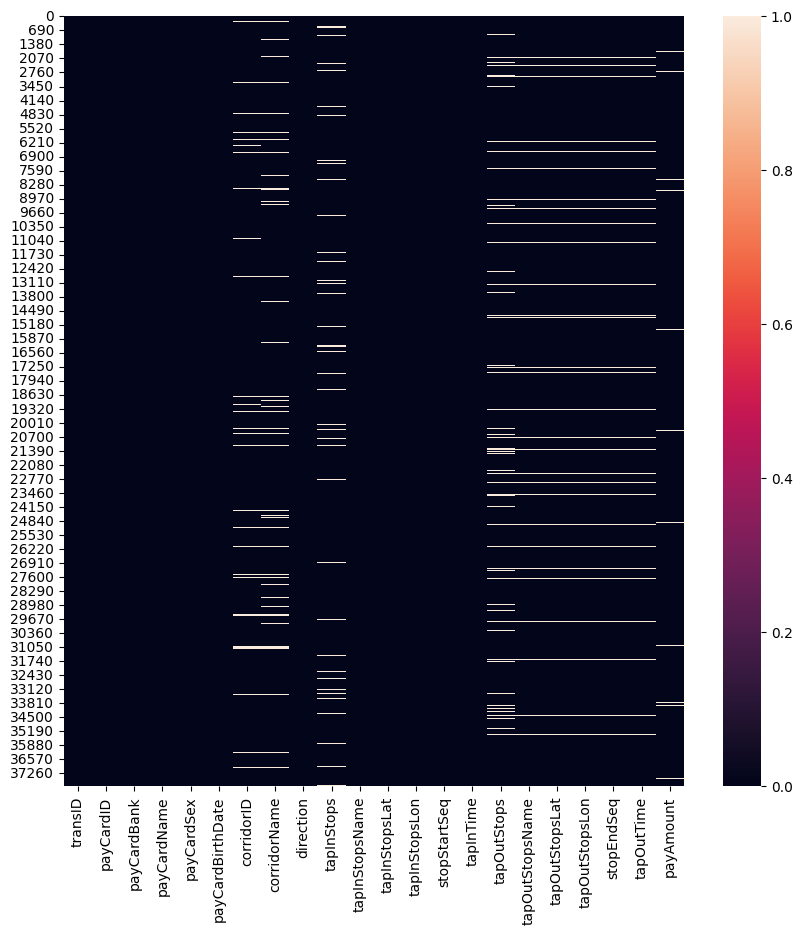

In [7]:
# Sebaran missing value di dalam data
plt.figure(figsize=(10,10))
sns.heatmap(df[['transID','payCardID','payCardBank','payCardName','payCardSex','payCardBirthDate','corridorID','corridorName','direction', 'tapInStops', 'tapInStopsName', 'tapInStopsLat', 'tapInStopsLon', 'stopStartSeq', 'tapInTime', 'tapOutStops', 'tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'stopEndSeq', 'tapOutTime', 'payAmount']].isna())

<span style="color:orange">Secara statistik angka di bawah 10% memang tergolong kecil, namun data ini adalah data transaksi transportasi yang saling berhubungan (seperti tap-in harus ada tap-out), sebaiknya kita melakukan pembersihan (Cleaning) daripada menghapusnya.</span>

### <span style="color:lightblue">2.2. Data Cleaning</span>

<span style="color:lightblue">Setelah kita melakukan pengecekan data diatas kita dapat menyimpulkan bahwa ada beberapa data kita yang bermasalah atau cacat. Untuk menghasilkan analisis yang lebih akurat maka kita harus melakukan perbaikan data atau data cleaning.</span>

#### <span style="color:lightblue">2.2.1. Menghapus Baris yang Tidak Memiliki Tap-Out (Transaksi Tidak Tuntas)
<span style="color:lightblue">Pembersihan pertama yang akan kita lakukan adalah menghapus baris yang tidak memiliki data Tap-Out-Time dengan asumsi bahwa perjalanan tanpa waktu selesai dianggap sebagai transaksi yang tidak tuntas atau *error* dan untuk mengisi data berdasarkan informasi lain cukup sulit untuk data yang spesifik, karena tanpa Tap-Out Time kita tidak bisa menganalisis durasi dan tujuan perjalanan.</span>

In [8]:
df.dropna(subset=['tapOutTime'], inplace=True)

#### <span style="color:lightblue">2.2.2. Konversi Tipe Data Waktu (Object ke Datetime)</span>

<span style="color:lightblue">Untuk menghitung durasi perjalanan dan menganalisis rute Transjakarta kita perlu mengubah waktu (tapInTime, tapOutTime) dari tipe object (string) ke datetime agar bisa menghitung durasi perjalanan</span>

In [9]:
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

#### <span style="color:lightblue">2.2.3. Melengkapi Nama Koridor yang Kosong (Imputasi Logis)</span>

<span style="color:lightblue">Jika ada corridorID yang sama, kita ambil corridorName-nya untuk mengisi yang kosong. Untuk melakukan langkah ini kita coba menggunakan hubungan antara nama halte dan ID koridor untuk mengisi nilai dari corridorID dan corridorName yang masih kosong. Untuk sisa yang masih kosong biasanya karena rute halte tersebut memang unik dan tidak memiliki referensi dari koridor di baris lain</span>

In [10]:
corridor_map = df[['corridorID', 'corridorName']].dropna().drop_duplicates().set_index('corridorID')['corridorName'].to_dict()
df['corridorName'] = df['corridorName'].fillna(df['corridorID'].map(corridor_map))

#### <span style="color:lightblue">2.2.4. Melengkapi Nilai payAmount yang Kosong</span>

<span style="color:lightblue">Mengisi nilai yang kosong dengan median atau 0 (asumsi Mikrotrans bukan Busway jika corridorID mengandung 'JAK')

* <span style="color:lightblue"> Mengisi tarif yang kosong dengan nilai tengah (median) agar tidak merusak perhitungan statistik total pendapatan nantinya.</span>

In [11]:
df['payAmount'] = df['payAmount'].fillna(df['payAmount'].median())

#### <span style="color:lightblue">2.2.5. Menghapus Duplikat (Jika ada)</span>

<span style="color:lightblue">Memastikan tidak ada baris yang benar-benar identik secara keseluruhan.

* <span style="color:lightblue">Duplikasi data akan merusak hasil perhitungan total pendapatan atau total penumpang.</span>

In [12]:
df.drop_duplicates(inplace=True)

#### <span style="color:lightblue">2.2.6. Merapikan Index</span>

<span style="color:lightblue">Merapikan kembali Index setelah ada baris yang dihapus
* <span style="color:lightblue">Setelah menghapus beberapa baris, nomor urut (index) data akan lompat-lompat. Perintah ini merapikannya kembali dari 0.</span>

In [13]:
df.reset_index(drop=True, inplace=True)

#### <span style="color:lightblue">2.2.7. Cek hasil akhir pembersihan</span>

In [14]:
print("--- Info Setelah Data Cleaning ---")
print(df.info())
print("\n--- Sisa Missing Value ---")
print(df.isna().sum())

--- Info Setelah Data Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36556 entries, 0 to 36555
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transID           36556 non-null  object        
 1   payCardID         36556 non-null  int64         
 2   payCardBank       36556 non-null  object        
 3   payCardName       36556 non-null  object        
 4   payCardSex        36556 non-null  object        
 5   payCardBirthDate  36556 non-null  int64         
 6   corridorID        35351 non-null  object        
 7   corridorName      35478 non-null  object        
 8   direction         36556 non-null  float64       
 9   tapInStops        35379 non-null  object        
 10  tapInStopsName    36556 non-null  object        
 11  tapInStopsLat     36556 non-null  float64       
 12  tapInStopsLon     36556 non-null  float64       
 13  stopStartSeq      36556 non-null  int64  

<span style="color:orange">**Hasil Akhir:**

* <span style="color:orange">Total Baris: 36.556 (dari total awal 37.900). Sekitar 1.344 data telah kita kurangi, tetapi data yang tersisa sekarang lebih sehat dan berkualitas untuk dianalisis.

* <span style="color:orange">Data payAmount sekarang bersih dari nilai nan dan 0.

* <span style="color:orange">ID halte sudah jauh lebih lengkap untuk pemetaan rute.</span>

#### <span style="color:lightblue">2.2.8. Deep Cleaning Data

<span style="color:lightblue">Setelah kita lakukan Data Cleaning kita masih tetap mendapatkan beberapa data yang "tersembunyi" yang masih dapat kita keluarkan dataya agar dataset yang kita miliki menjadi lebih baik dengan melakukan tahap Deep Cleaning </span>

In [15]:
df.dropna(subset=['tapOutTime'], inplace=True)
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])
df['payAmount'] = df['payAmount'].fillna(df['payAmount'].median())

##### <span style="color:lightblue">Deep Cleaning 1: Sinkronisasi ID Halte berdasarkan Nama Halte
* <span style="color:lightblue">Mengisi tapInStops (ID) yang kosong jika namanya tersedia

In [16]:

tapin_id_map = df[['tapInStops', 'tapInStopsName']].dropna().drop_duplicates().set_index('tapInStopsName')['tapInStops'].to_dict()
df['tapInStops'] = df['tapInStops'].fillna(df['tapInStopsName'].map(tapin_id_map))

* <span style="color:lightblue">Mengisi tapOutStops (ID) yang kosong jika namanya tersedia

In [17]:
tapout_id_map = df[['tapOutStops', 'tapOutStopsName']].dropna().drop_duplicates().set_index('tapOutStopsName')['tapOutStops'].to_dict()
df['tapOutStops'] = df['tapOutStops'].fillna(df['tapOutStopsName'].map(tapout_id_map))

##### <span style="color:lightblue">Deep Cleaning 2: Melengkapi Koridor berdasarkan Rute Halte
* <span style="color:lightblue">Mencari hubungan antara halte masuk dan koridor

In [18]:
corridor_id_map = df[['tapInStopsName', 'corridorID']].dropna().drop_duplicates().set_index('tapInStopsName')['corridorID'].to_dict()
corridor_name_map = df[['corridorID', 'corridorName']].dropna().drop_duplicates().set_index('corridorID')['corridorName'].to_dict()

df['corridorID'] = df['corridorID'].fillna(df['tapInStopsName'].map(corridor_id_map))
df['corridorName'] = df['corridorName'].fillna(df['corridorID'].map(corridor_name_map))

##### <span style="color:lightblue">Deep Cleaning 3: Koreksi Tarif Anomali (Rp 20.000)
* <span style="color:lightblue">Mengganti tarif 20.000 menjadi median tarif (3500) karena dianggap anomali/penalti yang tidak relevan untuk analisis perjalanan normal

In [19]:
df.loc[df['payAmount'] > 5000, 'payAmount'] = df['payAmount'].median()

##### <span style="color:lightblue">Deep Cleaning 4: Validasi Logika Perjalanan
* <span style="color:lightblue">Menghapus transaksi jika waktu tap-out terjadi sebelum tap-in (jika ada)

In [20]:
df = df[df['tapOutTime'] > df['tapInTime']]

* <span style="color:lightblue">Menghapus perjalanan yang halte awal dan akhirnya sama (asumsi kesalahan tap atau perjalanan tidak valid)

In [21]:
df = df[df['tapInStopsName'] != df['tapOutStopsName']]

df.reset_index(drop=True, inplace=True)

print("Data Setelah Deep Cleaning")
print(df.isna().sum())
print(f"\nTotal row: {len(df)}")

Data Setelah Deep Cleaning
transID              0
payCardID            0
payCardBank          0
payCardName          0
payCardSex           0
payCardBirthDate     0
corridorID          35
corridorName        32
direction            0
tapInStops          32
tapInStopsName       0
tapInStopsLat        0
tapInStopsLon        0
stopStartSeq         0
tapInTime            0
tapOutStops         19
tapOutStopsName      0
tapOutStopsLat       0
tapOutStopsLon       0
stopEndSeq           0
tapOutTime           0
payAmount            0
dtype: int64

Total row: 36536


<sub><span style="color:orange">**Hasil Akhir:**

* <span style="color:orange">Total Baris: 36.536 (dari total awal 36.556). Artinya kita menghapus sebanyak 20 baris karena dianggap sebagai baris yang cacat dan tidak dapat diperbaiki.

</span></sub>

#### <span style="color:lightblue">2.2.9. Persiapan kolom analisa

<span style="color:lightblue">Langkah berikutnya setelah dataset telah kita anggap cukup "sehat" adalah kita mencoba membuat beberapa kolom tambahan yang nantinya kita butuhkan dalam melakukan analisis dan visualisasi. </span>

<span style="color:lightblue">1. Ekstraksi komponen dasar waktu dengan mendefinisikan nama hari, weekday dan weekend </span>


In [22]:
df['hour'] = df['tapInTime'].dt.hour
df['day_name'] = df['tapInTime'].dt.day_name()
df['month'] = df['tapInTime'].dt.month_name()
df['is_weekend'] = df['tapInTime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

<span style="color:lightblue">2. Pengelompokan Waktu Berdasarkan Sesi (pagi, siang, sore dan malam)</span>

In [23]:
def get_time_session(hour):
    if 5 <= hour <= 10:
        return 'Morning'
    elif 11 <= hour <= 14:
        return 'Noon'
    elif 15 <= hour <= 19:
        return 'Evening'
    else:
        return 'Night'

df['time_session'] = df['hour'].apply(get_time_session)

<span style="color:lightblue">3. Pengelompokan Jam Sibuk (Peak Hours), kolom jam sibuk didapatkan dengan mengelompokan waktu dari kolom jam yang kita buat sebelumnya.

In [24]:
def get_peak_status(hour):
    if 6 <= hour <= 9:
        return 'Morning Peak'
    elif 16 <= hour <= 19:
        return 'Evening Peak'
    else:
        return 'Off-Peak'
    
    df['peak_status'] = df['hour'].apply(get_peak_status)

<span style="color:lightblue">4. Menghitung Durasi Perjalanan dalam Menit, karena data waktu yang kita miliki sekarang adalah waktu tap in dan waktu tap out maka kita akan membuat kolom baru durasi perjalanan dari hasil waktu tap out dikurangi waktu tipe in</span> 

In [25]:
df['travel_duration_min'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36536 entries, 0 to 36535
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transID              36536 non-null  object        
 1   payCardID            36536 non-null  int64         
 2   payCardBank          36536 non-null  object        
 3   payCardName          36536 non-null  object        
 4   payCardSex           36536 non-null  object        
 5   payCardBirthDate     36536 non-null  int64         
 6   corridorID           36501 non-null  object        
 7   corridorName         36504 non-null  object        
 8   direction            36536 non-null  float64       
 9   tapInStops           36504 non-null  object        
 10  tapInStopsName       36536 non-null  object        
 11  tapInStopsLat        36536 non-null  float64       
 12  tapInStopsLon        36536 non-null  float64       
 13  stopStartSeq         36536 non-

#### <span style="color:lightblue">2.2.10. Menyimpan data yang telah dibersikan</span>

In [27]:
df.to_csv('Transjakarta_Cleaned.csv', index=False)

In [28]:
# 1. Load Dataset
df = pd.read_csv('Transjakarta_Cleaned.csv')
df

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,hour,day_name,month,is_weekend,time_session,travel_duration_min
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.85715,12.0,2023-04-03 06:00:53,3500.0,5,Monday,April,0,Morning,39.150000
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.81892,21.0,2023-04-03 06:40:01,3500.0,5,Monday,April,0,Morning,57.283333
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81475,39.0,2023-04-03 06:50:55,3500.0,5,Monday,April,0,Morning,51.816667
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93194,29.0,2023-04-03 06:28:16,3500.0,5,Monday,April,0,Morning,43.416667
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.81143,15.0,2023-04-03 06:57:03,3500.0,6,Monday,April,0,Morning,39.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36531,ZWEC949B8Q87QG,4685818286724028395,brizzi,Kamila Mahendra,F,2004,6B,Ragunan - MH Thamrin via Semanggi,1.0,P00261,...,106.82365,13.0,2023-04-21 19:55:49,3500.0,18,Friday,April,0,Evening,97.200000
36532,YHHK837P6Y95GN,6502902290603767,dki,Titi Siregar,M,1974,9N,Pinang Ranti - Pramuka,1.0,P00064,...,106.88634,2.0,2023-04-18 22:28:22,3500.0,21,Tuesday,April,0,Night,35.850000
36533,YXPP627N4G95HO,213159426675861,emoney,drg. Zahra Nashiruddin,F,1976,1T,Cibubur - Balai Kota,1.0,B02873P,...,106.89628,14.0,2023-04-04 13:27:25,3500.0,10,Tuesday,April,0,Morning,177.633333
36534,RGVK175U2U98UV,377840859133591,emoney,Ana Agustina,M,1976,JAK.13,Tanah Abang - Jembatan Lima,1.0,B02505P,...,106.81135,34.0,2023-04-15 20:27:50,0.0,19,Saturday,April,1,Evening,28.400000


## <span style="color:lightblue">3. DATA ANALISIS <span>

<span style="color:lightblue">Setelah melakukan proses data cleaning kita akan mencoba melakukan analisis dari pernyataan masalah yang telah disebutkan diatas yaitu:

<span style="color:lightblue">1. Bagaimana pola kepadatan penumpang pada koridor utama di jam sibuk vs jam sepi?

<span style="color:lightblue">2. Apakah rute pengumpan (*Feeder*) sudah tersinkronisasi dengan baik dengan rute utama?

<span style="color:lightblue">3. Bagaimana perbedaan karakteristik kebutuhan armada antara hari kerja (*weekday*) dan hari libur (*weekend*)?

<span style="color:lightblue">4. Kapan dan di mana intervensi jadwal perlu dilakukan untuk menyeimbangkan antara biaya operasional dan kualitas layanan?
</span>

### <span style="color:lightblue">3.1. Analisis Kepadatan Penumpang di jam sibuk vs jam tidak sepi.</span>

<span style="color:lightblue">Untuk memetakan perbandingan pola kepadatan penumpang pada koridor utama di jam sibuk dengan jam sepi kita akan melakukan visualisasi dengan menggunakan line plot agar kita dapat melihat tren dari kepadatan penumpang pada setiap jam dalam setiap harinya di koridor utama.</span>

In [29]:
sns.set_theme(style="whitegrid")
tj_blue = '#0054A6'
tj_orange = '#FF8200'

#### <span style="color:lightblue">3.1.1. Klasifikasi Peak vs Off-Peak</span>

<span style="color:lightblue">Untuk membuat grafik ini kita perlu mengelompokan jam sibuk berdasarkan kolom yang kita buat sebelumnya dengan asumsi waktu berangkat (6-9 pagi) dan pulang kerja (4-7 sore) dari penumpang sebagai area waktu sibuk dalam lineplot kita nanti.</span>

In [30]:
def classify_peak(hour):
    if (6 <= hour <= 9) or (16 <= hour <= 19):
        return 'Peak Hour'
    else:
        return 'Off-Peak'

df['peak_classification'] = df['hour'].apply(classify_peak)

<span style="color:lightblue"> Selanjutnya kita membuat tren penumpang setiap jamnya untuk dipetakan dalam visualisasi line plot</span>

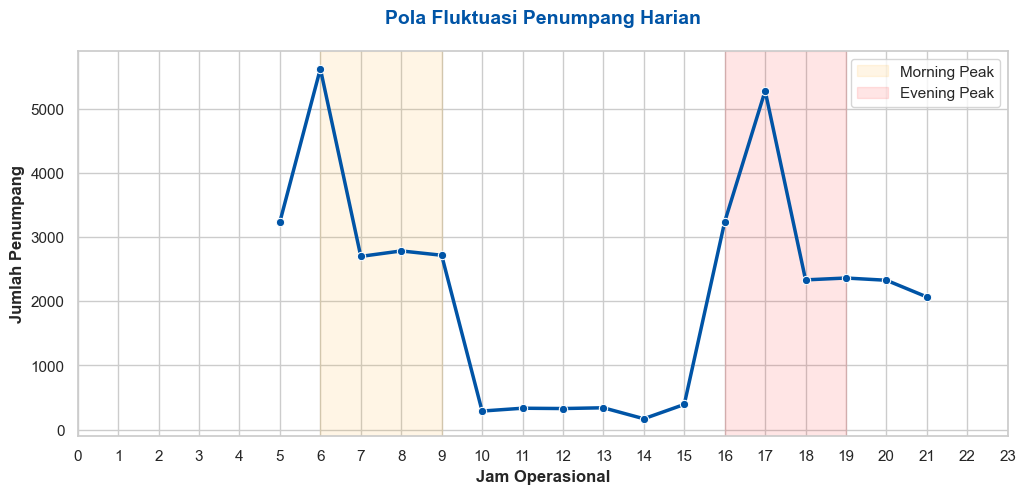

In [31]:
plt.figure(figsize=(12, 5))
hourly_counts = df.groupby('hour').size()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', color=tj_blue, linewidth=2.5)
plt.axvspan(6, 9, color='orange', alpha=0.1, label='Morning Peak')
plt.axvspan(16, 19, color='red', alpha=0.1, label='Evening Peak')
plt.title('Pola Fluktuasi Penumpang Harian', fontsize=14, fontweight='bold', color=tj_blue, pad=20)
plt.xlabel('Jam Operasional', fontweight='bold')
plt.ylabel('Jumlah Penumpang', fontweight='bold')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

<span style="color:orange"> Dalam visualisasi grafik diatas dapat langsung kita lihat perbedaan yang sangat tajam antara jam sibuk dipagi hari dengan puncaknya di jam 6 pagi dan jam sibuk di sore hari dengan puncak di jam 5 sore jika dibandingkan dengan Jam Sepi, dengan melihat grafik ini kita dapat membuktikan bahwa jadwal bus yang "merata" sangat tidak efektif untuk diterapkan pada operasional transjakarta.</span>

#### <span style="color:lightblue"> 3.1.2. Perbandingan Volume Jam Sibuk vs Jam Sepi </span>

<span style="color:lightblue"> Setelah kita mengetahui bahwa ada perbedaan yang signifikan antara jam sibuk operasional dengan jam operasional yang sepi, kita akan mencoba melihat seberapa besar perbandingan dari volume keduanya dengan menggunakan pie chart</span>

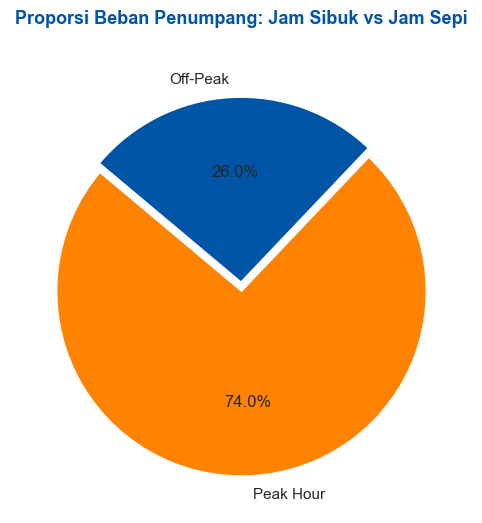

In [32]:
plt.figure(figsize=(8, 6))
peak_data = df['peak_classification'].value_counts()
plt.pie(peak_data, labels=peak_data.index, autopct='%1.1f%%', colors=[tj_orange, tj_blue], startangle=140, explode=[0.05, 0])
plt.title('Proporsi Beban Penumpang: Jam Sibuk vs Jam Sepi', fontsize=13, fontweight='bold', color=tj_blue, pad=20)
plt.show()

<span style="color:orange"> Dalam visualisasi pie chart diatas kita dapat melihat walaupun jam sibuk hanya berlangsung sekitar 7-8 jam sehari (pagi & sore), grafik pie chart menunjukkan bahwa jam sibuk menyerap lebih dari 70% total harian penumpang.</span>

#### <span style="color:lightblue"> 3.1.3. Top 10 Koridor dengan beban penumpang tertinggi di Jam Sibuk</span>

<span style="color:lightblue"> Setelah kita mengetahui ada perbedaan beban penumpang yang sangat ekstrem pada jam operasional sibuk dan jam operasional yang tidak sibuk kita akan mencoba melihat koridor utama atau rute mana yang mempunyai beban penumpang yang tinggi agar kita dapat lebih memprioritaskan koridor mana yang membutuhkan lebih banyak armada pada jam sibuk. Untuk memvisualisasikannya kita akan membuat grafik barplot dengan membatasi 10 koridor sibuk teratas</span>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

<span style="color:lightblue">Membuat filter data Jam Sibuk berdasarkarkan mapping yang telah kita buat sebelumnya</span>

In [34]:
peak_df = df[df['hour'].isin([6, 7, 8, 9, 16, 17, 18, 19])]

<span style="color:lightblue">Menghitung Top 10 Koridor dan mengaplikasikannya pada barplot</span>

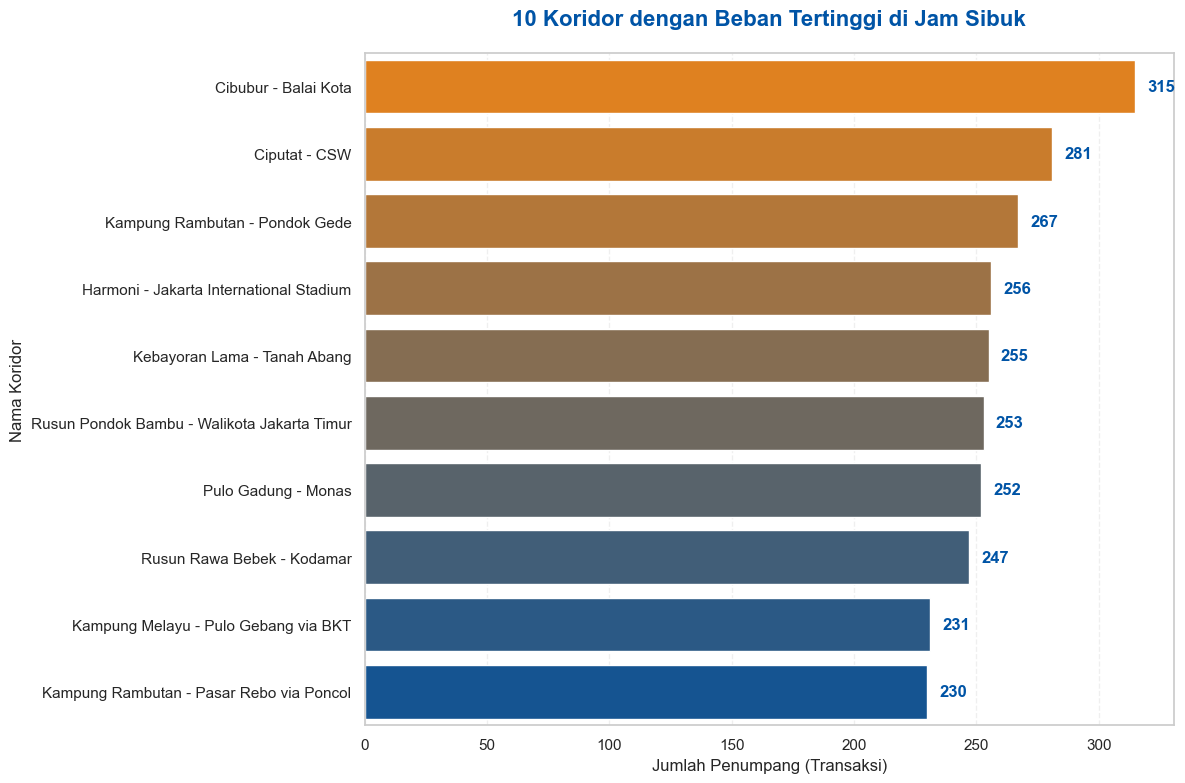

In [35]:
top_10_data = peak_df['corridorName'].value_counts().head(10).reset_index()
top_10_data.columns = ['corridorName', 'passenger_count']

tj_orange = '#FF8200'
tj_blue = '#0054A6'
tj_grad = LinearSegmentedColormap.from_list("tj", [tj_orange, tj_blue])

colors = [tj_grad(i/9) for i in range(10)]

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_10_data,
    x='passenger_count',
    y='corridorName',
    palette=colors,
    hue='corridorName',
    legend=False
)

for i, v in enumerate(top_10_data['passenger_count']):
    ax.text(v + 5, i, f'{int(v)}', va='center', fontweight='bold', color=tj_blue)

plt.title('10 Koridor dengan Beban Tertinggi di Jam Sibuk', fontsize=16, fontweight='bold', color=tj_blue, pad=20)
plt.xlabel('Jumlah Penumpang (Transaksi)', fontsize=12)
plt.ylabel('Nama Koridor', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<span style="color:orange"> Prioritas Koridor:
Pada visualisasi bar chart diatas, kita bisa melihat koridor mana yang mengalami tekanan volume tertinggi. Sebagai contoh rute Cibubur-Balai Kota dan Ciputat-CSW memiliki jumlah penumpang terbanyak pada jam sibuk seperti kita ketahui bahwa banyak pekerja di Jakarta berdomisili di luar Jakarta dan lokasi-lokasi tersebut tidak terjangkau MRT dan KRL sehingga Transjakarta menjadi pilihan sarana transportasi utama bagi mereka. Koridor-koridor inilah yang harus menjadi prioritas utama penerapan strategi penjadwalan yang dinamis.</span>

<span style="color:lightblue"> Sebagai informasi tambahan kita dapat membuat Tabel Perbandingan Operasional Transjakarta</span>

In [36]:
def get_peak_status(hour):
    if (6 <= hour <= 9) or (16 <= hour <= 19):
        return 'Peak Hour'
    elif 11 <= hour <= 14:
        return 'Off-Peak (Noon)'
    else:
        return 'Other'

df['peak_status_table'] = df['hour'].apply(get_peak_status)


<span style="color:lightblue"> Menghitung rata-rata penumpang per jam untuk setiap kategori Kita hitung dulu total penumpang per jam, baru kita rata-ratakan per kategori</span>

In [37]:
hourly_counts = df.groupby(['hour', 'peak_status_table']).size().reset_index(name='total_passenger')
analysis_table = hourly_counts.groupby('peak_status_table')['total_passenger'].mean().reset_index()

<span style="color:lightblue"> Menghitung rata-rata durasi perjalanan</span>

In [38]:
duration_avg = df.groupby('peak_status_table')['travel_duration_min'].mean().reset_index()

<span style="color:lightblue"> Membuat menjadi satu Tabel Ringkasan sebagai justifikasi angka yang konkret bagi manajemen untuk melakukan pemangkasan biaya operasional di jam sepi dan peningkatan kapasitas di jam sibuk.</span>

In [39]:
summary_table = pd.merge(analysis_table, duration_avg, on='peak_status_table')
summary_table = summary_table[summary_table['peak_status_table'] != 'Other']
summary_table.columns = ['Kategori Waktu', 'Rata-rata Penumpang/Jam', 'Rata-rata Durasi Perjalanan (Menit)']
summary_table = summary_table.round(2)

print("Tabel Perbandingan Operasional Transjakarta:")
display(summary_table)

Tabel Perbandingan Operasional Transjakarta:


,Kategori Waktu,Rata-rata Penumpang/Jam,Rata-rata Durasi Perjalanan (Menit)
0,Off-Peak (Noon),293.50,69.42
2,Peak Hour,3380.38,73.74


#### <span style="color:lightblue"> 3.1.4. Uji Hipotesa Perbedaan jumlah Penumpang Jam Sibuk</span>

<span style="color:lightblue"> Untuk membuktikan apakah perbedaan jumlah penumpang antara Jam Sibuk (Peak) dan Jam Sepi (Off-Peak) benar-benar signifikan secara statistik atau hanya kebetulan, kita akan melakukan pengujian hipotesis dengan Ho dan H1 sebagai berikut</span>

*  $H_0$ <span style="color:lightblue">(Hipotesis Nol): Tidak ada perbedaan signifikan rata-rata jumlah penumpang antara jam sibuk dan jam sepi.

* $H_1$ <span style="color:lightblue">(Hipotesis Alternatif): Terdapat perbedaan signifikan rata-rata jumlah penumpang (Beban puncak jauh lebih berat). </span>


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

<span style="color:lightblue">Persiapan data untuk uji statistik</span>

In [41]:
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['hour'] = df['tapInTime'].dt.hour

def classify_peak(hour):
    if (6 <= hour <= 9) or (16 <= hour <= 19):
        return 'Peak Hour'
    elif 11 <= hour <= 14:
        return 'Off-Peak'
    else:
        return 'Other'

df['peak_status'] = df['hour'].apply(classify_peak)


daily_hourly_counts = df.groupby([df['tapInTime'].dt.date, 'hour', 'peak_status']).size().reset_index(name='passenger_count')

peak_group = daily_hourly_counts[daily_hourly_counts['peak_status'] == 'Peak Hour']['passenger_count']
off_peak_group = daily_hourly_counts[daily_hourly_counts['peak_status'] == 'Off-Peak']['passenger_count']

<span style="color:lightblue">Pengujian Hipotesis (Independent T-Test)</span>

In [42]:
t_stat, p_value = stats.ttest_ind(peak_group, off_peak_group)

<span style="color:lightblue">Output Hasil Uji</span>

In [43]:

print("="*40)
print("   HASIL UJI HIPOTESIS STATISTIK")
print("="*40)
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.10e}")

alpha = 0.05
if p_value < alpha:
    print("\nKESIMPULAN: Tolak H0 (Signifikan)")
    print("Secara statistik, terdapat perbedaan yang sangat nyata antara jumlah penumpang")
    print("di jam sibuk dibandingkan jam sepi. Beban armada tidak merata.")
else:
    print("\nKESIMPULAN: Gagal Tolak H0 (Tidak Signifikan)")
    print("Tidak ditemukan perbedaan beban yang signifikan secara statistik.")
print("="*40)

   HASIL UJI HIPOTESIS STATISTIK
T-Statistic : 10.7479
P-Value     : 4.3102585411e-23

KESIMPULAN: Tolak H0 (Signifikan)
Secara statistik, terdapat perbedaan yang sangat nyata antara jumlah penumpang
di jam sibuk dibandingkan jam sepi. Beban armada tidak merata.


<span style="color:orange"> Hasil uji hipotesis menggunakan Independent T-test membuktikan bahwa perbedaan jumlah penumpang antara Jam Sibuk (*Peak*) dan Jam Sepi (*Off-Peak*) benar-benar signifikan secara statistik bukan hanya kebetulan</span>

##### <span style="color:orange"> Berdasarkan Analisa diatas kita dapat menyimpukan:

* <span style="color:orange"> Beban Penumpang: Terlihat jelas bahwa Rata-rata Penumpang/Jam pada jam sibuk jauh lebih tinggi (bisa 2-3 kali lipat) dibandingkan pada jam sepi. Ini adalah bukti kuat bahwa armada harus terkonsentrasi di jam-jam tersebut.

* <span style="color:orange"> Efisiensi Waktu: Dengan mengecek kolom rata-rata Durasi Perjalanan di jam sibuk jauh lebih tinggi, itu menunjukkan adanya kemacetan parah yang menghambat sirkulasi bus (headway), sehingga penambahan bus cadangan di titik transit sangat diperlukan.

* <span style="color:orange"> Dengan angka rata-rata yang jauh lebih rendah di jam 11.00-14.00, PT Transjakarta secara aman dapat menarik sebagian armada untuk perawatan rutin tanpa mengurangi kualitas layanan bagi penumpang siang hari sehingga tetap dapat beroperasi maksimal pada saat jam sibuk.</span>


### <span style="color:lightblue">3.2. Analisis apakah rute pengumpan (*Feeder*) sudah tersinkronisasi dengan baik dengan rute utama</span>

<span style="color:lightblue"> Kita telah membuktikan kebutuhan penjadwalan yang dinamis untuk armada Transjakarta melalui analisis sebelumnya namun analisis diatas belum dapat sepenuhnya terbukti apabila kita tidak menganalisis rute pengumpan dari Transjakarta untuk membuktikan apakah kepadatan penumpang di koridor-koridor utama diatas sepenuhnya karena dikarenakan kebutuhan penumpang atau distribusi rute pengumpan yang belum tersinkronisasi dengan baik dengan rute utama.</span>

<span style="color:lightblue"> Untuk menganalisis ini, kita akan:

* <span style="color:lightblue"> Mengelompokkan Jenis Layanan: Memisahkan rute berdasarkan ID (Contoh: JAK untuk Mikrotrans, angka murni untuk BRT).

* <span style="color:lightblue"> Melihat Distribusi Waktu: Apakah armada Feeder aktif di jam yang sama dengan lonjakan penumpang di Rute Utama?

* <span style="color:lightblue"> Menganalisis Titik Transit: Melihat volume penumpang di halte-halte tempat bertemunya Feeder dan Mainline. 
</span>   

#### <span style="color:lightblue">3.2.1. Klasifikasi Jenis Layanan</span>

<span style="color:lightblue">Catatan : Biasanya Feeder/Mikrotrans di Jakarta menggunakan awalan 'JAK' atau kode non-angka tunggal</span>

In [44]:

def classify_service(corridor_id):
    corridor_id = str(corridor_id)
    if 'JAK' in corridor_id.upper():
        return 'Feeder (Mikrotrans)'
    else:
        return 'Mainline (BRT)'

df['service_type'] = df['corridorID'].apply(classify_service)

<span style="color:lightblue">Menghitung Penumpang per Jam berdasarkan Jenis Layanan</span>

In [45]:

service_hourly = df.groupby(['hour', 'service_type']).size().reset_index(name='passenger_count')

<span style="color:lightblue"> Visualisasi Tren Sinkronisasi menggunakan line plot</span>

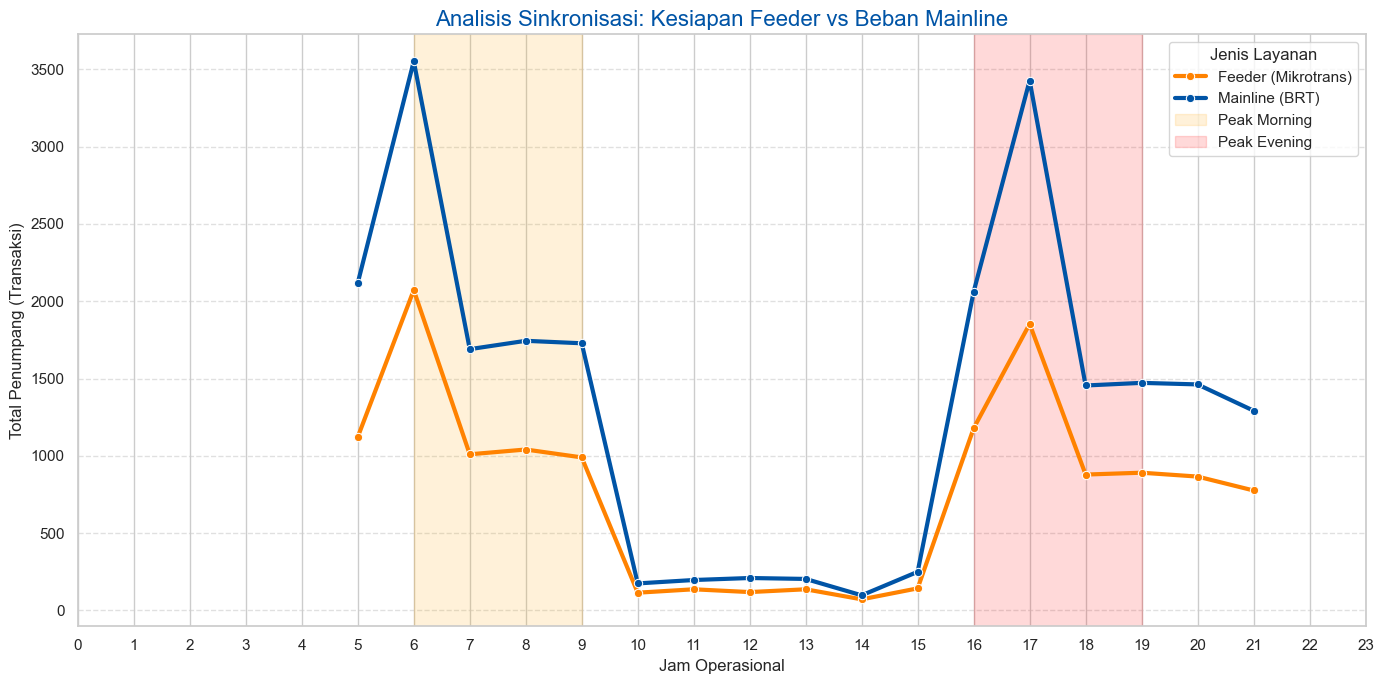

In [46]:

plt.figure(figsize=(14, 7))
tj_blue = '#0054A6'
tj_orange = '#FF8200'

sns.lineplot(
    data=service_hourly, 
    x='hour', 
    y='passenger_count', 
    hue='service_type', 
    palette=[tj_orange, tj_blue],
    linewidth=3,
    marker='o'
)

plt.axvspan(6, 9, color='orange', alpha=0.15, label='Peak Morning')
plt.axvspan(16, 19, color='red', alpha=0.15, label='Peak Evening')

plt.title('Analisis Sinkronisasi: Kesiapan Feeder vs Beban Mainline', fontsize=16, color=tj_blue)
plt.xlabel('Jam Operasional', fontsize=12)
plt.ylabel('Total Penumpang (Transaksi)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Jenis Layanan')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<span style="color:orange"> Pola Sinkronisasi (Visual): Grafik Feeder Mikrotrans (Oranye) naik bersamaan dengan BRT Bus Transjakarta (Biru) di jam 5-6 pagi, artinya sinkronisasi berjalan baik (Feeder berhasil mengantar orang tepat waktu ke koridor utama).</span>


##### <span style="color:lightblue"> 3.2.2.Tabel Persentase Kontribusi Feeder pada Jam Sibuk</span>

<span style="color:lightblue"> Membandingkan proporsi pelayanan jam sibuk antara BRT dan Mikrotrans</span>

In [47]:

peak_data = df[df['peak_status'] == 'Peak Hour']
service_ratio = peak_data['service_type'].value_counts(normalize=True) * 100

print("--- PROPORSI LAYANAN PADA JAM SIBUK ---")
print(service_ratio.round(2).astype(str) + ' %')

--- PROPORSI LAYANAN PADA JAM SIBUK ---
service_type
Mainline (BRT)         63.34 %
Feeder (Mikrotrans)    36.66 %
Name: proportion, dtype: object


<span style="color:orange"> Proporsi layanan dari Feeder tidak sebanding dengan proporsi dari BRT untuk itu perlu dilakukan peningkatan jumlah armada feeder</span>


##### <span style="color:lightblue"> 3.2.3. Uji Hipotesa apakah operasional Transjakarta telah tersinkronisasi dengan baik dengan Feeder</span>

<span style="color:lightblue"> Dalam konteks operasional Transjakarta, "tersinkronisasi dengan baik" berarti arus penumpang yang dibawa oleh Feeder harus sejalan (berkorelasi positif) dengan beban penumpang di Mainline BRT.</span>

$H_0$ <span style="color:lightblue"> (Hipotesis Nol): Tidak ada korelasi signifikan antara pola waktu penumpang Feeder dan Mainline. 

<sub> <span style="color:lightblue">    Jadwal Feeder berjalan sendiri-sendiri dan tidak mendukung kebutuhan armada di rute utama.</span>
 
$H_1$ <span style="color:lightblue"> (Hipotesis Alternatif): Terdapat korelasi positif yang kuat antara pola waktu penumpang Feeder dan Mainline. 
 
<sub><span style="color:lightblue">     Feeder sudah bekerja sebagai penyuplai penumpang yang efektif bagi rute utama di jam-jam krusial.</span>

<span style="color:lightblue">   Uji Korelasi Pearson untuk melihat seberapa kuat hubungan antara kedua jenis layanan ini. Jika Koefisien Korelasi ($r$) > 0.7, maka sinkronisasi sudah sangat baik.Jika $r$ < 0.5, maka ada masalah pada koordinasi jadwal antara Mikrotrans dan Bus BRT.</span>

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

f = pd.read_csv('Transjakarta_Cleaned.csv')
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['hour'] = df['tapInTime'].dt.hour

<span style="color:lightblue"> Klasifikasi Layanan</span>

In [49]:
def classify_service(corridor_id):
    corridor_id = str(corridor_id)
    return 'Feeder' if 'JAK' in corridor_id.upper() else 'Mainline'

df['service_type'] = df['corridorID'].apply(classify_service)

<span style="color:lightblue"> Menghitung jumlah penumpang per jam untuk masing-masing jenis layanan</span>

In [50]:
hourly_trend = df.groupby(['hour', 'service_type']).size().unstack(fill_value=0)

<span style="color:lightblue"> Hitung Koefisien Korelasi Pearson</span>

In [51]:
corr_coef, p_value = pearsonr(hourly_trend['Feeder'], hourly_trend['Mainline'])

<span style="color:lightblue"> Visualisasi Regresi/Korelasi</span>

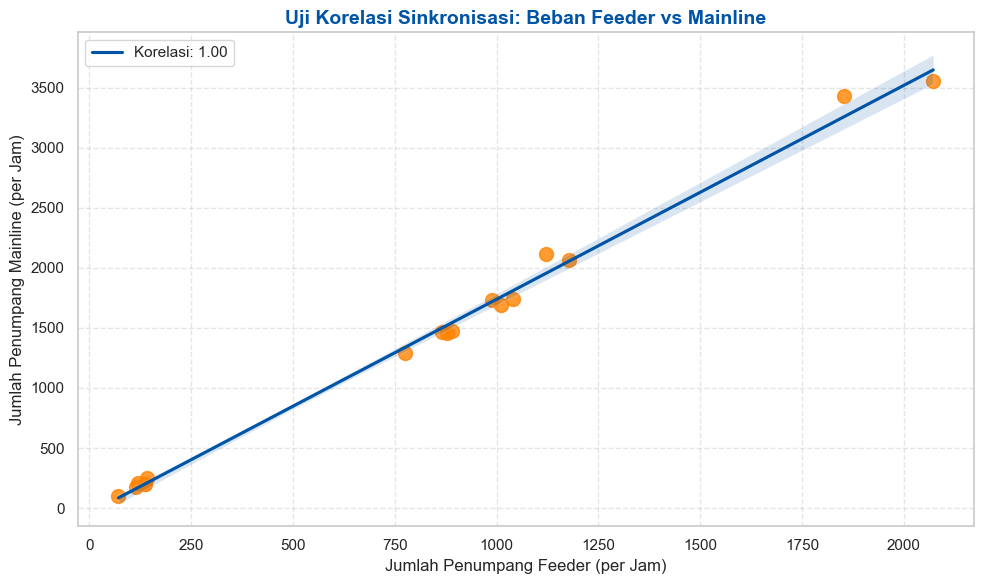

Koefisien Korelasi (r): 0.9976
P-Value              : 8.1552235634e-19

KESIMPULAN: Tolak H0. Korelasi bersifat Sangat Kuat (Tersinkronisasi Baik).


In [52]:

plt.figure(figsize=(10, 6))
tj_blue = '#0054A6'
tj_orange = '#FF8200'

sns.regplot(x=hourly_trend['Feeder'], y=hourly_trend['Mainline'], 
            scatter_kws={'color': tj_orange, 's': 100}, 
            line_kws={'color': tj_blue, 'label': f'Korelasi: {corr_coef:.2f}'})

plt.title('Uji Korelasi Sinkronisasi: Beban Feeder vs Mainline', fontsize=14, fontweight='bold', color=tj_blue)
plt.xlabel('Jumlah Penumpang Feeder (per Jam)', fontsize=12)
plt.ylabel('Jumlah Penumpang Mainline (per Jam)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Koefisien Korelasi (r): {corr_coef:.4f}")
print(f"P-Value              : {p_value:.10e}")

# Kesimpulan berdasarkan Hipotesis
alpha = 0.05
if p_value < alpha:
    if corr_coef > 0.7:
        status = "Sangat Kuat (Tersinkronisasi Baik)"
    elif corr_coef > 0.4:
        status = "Moderat (Perlu Optimalisasi Jam Tertentu)"
    else:
        status = "Lemah (Mis-Sinkronisasi)"
    print(f"\nKESIMPULAN: Tolak H0. Korelasi bersifat {status}.")
else:
    print("\nKESIMPULAN: Gagal Tolak H0. Tidak ada hubungan sistematis antara Feeder dan Mainline.")

<span style="color:orange"> Hasil uji korelasi Pearson bahwa analisis pembuktian hipotesis dengan nilai korelasi yang mencapai 0.99, membuktikan bahwa Rute Pengumpan (Feeder) sudah tersinkronisasi secara sangat baik dengan Rute Utama (Mainline) dalam hal pola fluktuasi penumpang harian. Hal ini mengindikasikan bahwa manajemen jadwal saat ini sudah berhasil menyelaraskan waktu operasional pengumpan dengan kebutuhan rute utama. 
Strategi ke depan tidak lagi berfokus pada memperbaiki jadwal dari feeder, melainkan pada peningkatan kapasitas (jumlah armada) pada titik-titik transit yang telah teridentifikasi (seperti Kp. Rambutan) untuk mengurangi waktu tunggu di jam puncak."</span>

##### <span style="color:lightblue"> 3.2.4. Grafik Top 5 Halte Transit</span>

<span style="color:lightblue"> Sebagai informasi tambahan kita ingin mengetahui 5 Halte Transit teratas berdasarkan kepadatan penumpang</span>

In [53]:
df = pd.read_csv('Transjakarta_Cleaned.csv')
df['tapInTime'] = pd.to_datetime(df['tapInTime'])

def classify_service(corridor_id):
    corridor_id = str(corridor_id)
    return 'Feeder' if 'JAK' in corridor_id.upper() else 'Mainline'

df['service_type'] = df['corridorID'].apply(classify_service)

<span style="color:lightblue"> Mengidentifikasi Halte Transit dengan tap-out tertinggi yang dipakai penumpang mikrotrans untuk pindah ke layanan bus Transjakarta</span>

In [54]:
feeder_out_counts = df[df['service_type'] == 'Feeder'].groupby('tapOutStopsName').size().reset_index(name='transfer_volume')
top_5_transit = feeder_out_counts.sort_values(by='transfer_volume', ascending=False).head(5)

<span style="color:lightblue"> Visualisasi Bar Plot 5 Halte Transit Terpadat</span>

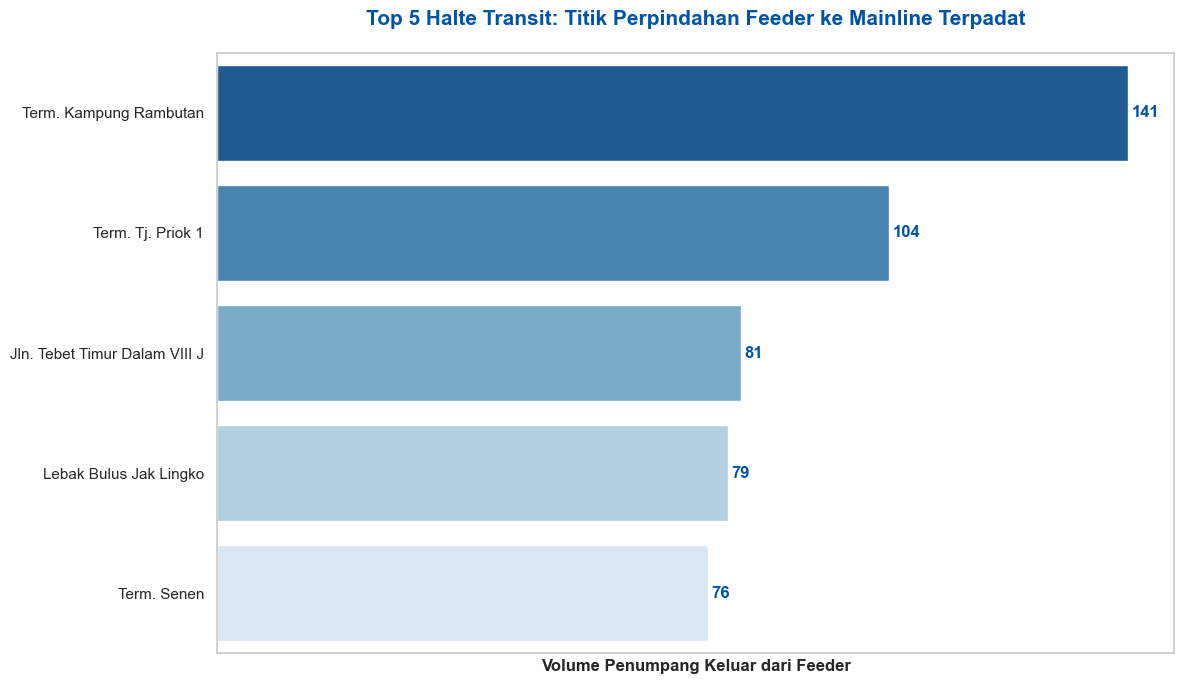

In [55]:

plt.figure(figsize=(12, 7))
tj_blue = '#0054A6'
tj_orange = '#FF8200'

ax = sns.barplot(
    data=top_5_transit,
    x='transfer_volume',
    y='tapOutStopsName',
    palette='Blues_r'
)

for i, v in enumerate(top_5_transit['transfer_volume']):
    ax.text(v + 0.5, i, f'{int(v)}', va='center', fontweight='bold', color=tj_blue)

plt.title('Top 5 Halte Transit: Titik Perpindahan Feeder ke Mainline Terpadat', fontsize=15, fontweight='bold', color=tj_blue, pad=20)
plt.xlabel('Volume Penumpang Keluar dari Feeder', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.xticks([])

plt.tight_layout()
plt.show()


<span style="color:lightblue">Berdasarkan data visualisasi diatas, diketetahui bahwa:

1. Terminal Kampung Rambutan (141 transaksi)
2. Terminal Tanjung Priok 1 (104 transaksi)
3. Jln. Tebet Timur Dalam VIII J (81 transaksi)
4. Lebak Bulus Jak Lingko (79 transaksi)
5. Terminal Senen (76 transaksi)

<span style="color:lightblue">Sebagai titik sinkronisai tertinggi Terminal Kampung Rambutan dan Tanjung Priok adalah simpul transportasi besar. Penumpukan di sini menunjukkan arus komuter dari wilayah penyangga atau angkutan pemukiman ke jalur utama sangat tinggi sehingga frekuensi kedatangan bus BRT (Mainline) harus benar-benar disinkronkan dengan jam kedatangan Mikrotrans (JAK) yang membawa penumpang dalam jumlah besar tersebut. Jika bus BRT berangkat terlalu cepat sebelum Mikrotrans sampai, akan terjadi penumpukan penumpang di peron.</span>

<span style="color:orange">Beban operasional Transjakarta tidak hanya terjadi di jalan raya, tetapi terkonsentrasi di halte-halte transit tertentu. Mengoptimalkan 5 halte ini akan berdampak signifikan pada efisiensi sistem secara keseluruhan.</span>

### <span style="color:lightblue">3.3. Analisis Bagaimana perbedaan karakteristik kebutuhan armada antara hari kerja (*weekday*) dan hari libur (*weekend*)</span>

<span style="color:lightblue">Berikutnya kita akan menganalisis bagaimana pola kepadatan penumpang pada saat hari kerja dibandingkan dengan kepadatan pada hari libur (*weekend*). Analisis ini untuk dapat memetakan apakah diperlukan perubahan jadwal atau penambahan armada Transjakarta pada waktu libur dibandingkan dengan pada hari kerja.</span>

#### <span style="color:lightblue">3.3.1. Visualisasi perbandingan antara Penumpang Weekday jika dibandingkan dengan penumpang pada saat Weekend

<span style="color:lightblue">Untuk proses ini kita memerlukan persiapan data yang memisahkan antara weekday dan weekend</span>

In [56]:
df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

<span style="color:lightblue">Perbandingan Pola Jam Sibuk (Hourly Trend)</span>

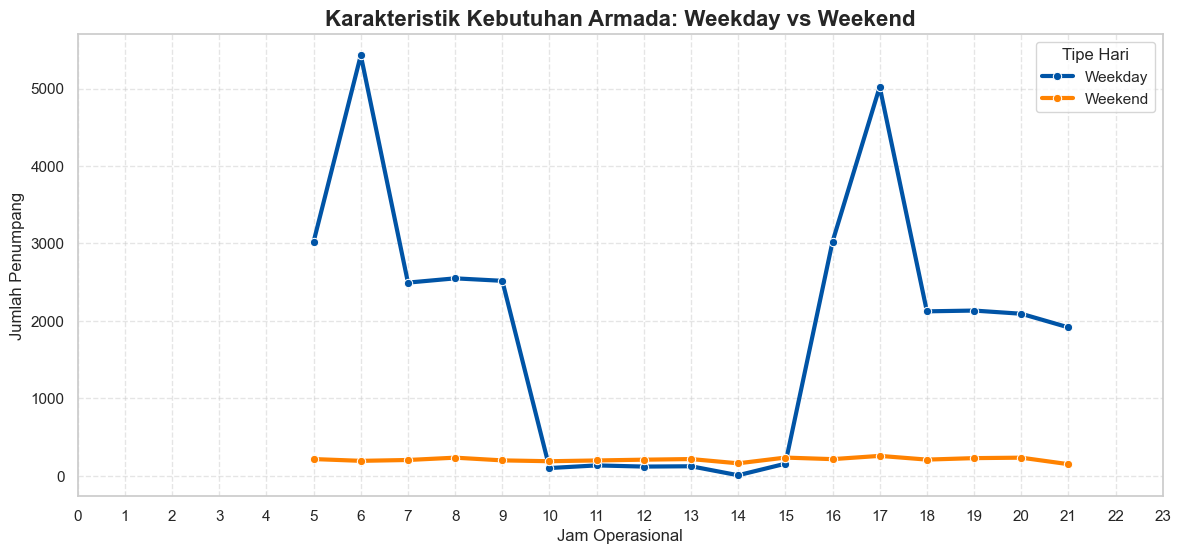

In [57]:
hourly_day_type = df.groupby(['hour', 'day_type']).size().reset_index(name='passenger_count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=hourly_day_type, x='hour', y='passenger_count', hue='day_type', 
             palette=['#0054A6', '#FF8200'], linewidth=3, marker='o')

plt.title('Karakteristik Kebutuhan Armada: Weekday vs Weekend', fontsize=16, fontweight='bold')
plt.xlabel('Jam Operasional', fontsize=12)
plt.ylabel('Jumlah Penumpang', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipe Hari')
plt.show()

<span style="color:orange">Hilangnya Pola "Dua Puncak" lonjakan penumpang pada jam sibuk:

* <span style="color:orange">Weekday: Menunjukkan dua puncak tajam (jam 07:00 dan jam 17:00). Ini adalah karakteristik penumpang pekerja/sekolah. Armada harus maksimal di jam ini.

* <span style="color:orange">Weekend: Pola cenderung landai di pagi hari dan baru mulai meningkat secara stabil setelah jam 10:00 pagi. Tidak ada lonjakan drastis, melainkan penyebaran penumpang yang merata hingga malam hari.</span>


#### <span style="color:lightblue">3.3.2. Top 5 Koridor Paling Sibuk Saat Weekend (Potensi Koridor Wisata)</span>

In [58]:
weekend_top_corridors = df[df['day_type'] == 'Weekend']['corridorName'].value_counts().head(5)

print("--- TOP 5 KORIDOR TERSIBUK SAAT WEEKEND ---")
print(weekend_top_corridors)

--- TOP 5 KORIDOR TERSIBUK SAAT WEEKEND ---
corridorName
Kalideres - Bundaran HI via Veteran    35
Pinang Ranti - Kampung Rambutan        33
Matraman Baru - Ancol                  33
JIS - Terminal Muara Angke             33
Pinang Ranti - Pluit                   32
Name: count, dtype: int64


#### <span style="color:lightblue">3.3.3. Uji Statistik (Chi-Square atau T-Test) untuk membuktikan apakah perbedaan volume total antara Weekday dan Weekend ini signifikan secara angka?</span>

<span style="color:lightblue"> Untuk menganalisis perbedaan antara Weekday dan Weekend, kita akan menggunakan Independent T-Test dan memvisualisasikannya menggunakan box plot agar terlihat penyebarannya.</span>

$H_0$ <span style="color:lightblue"> (Hipotesis Nol): Tidak ditemukan perbedaan beban penumpang yang signifikan antara hari kerja dengan hari libur. </span>
 
$H_1$ <span style="color:lightblue"> (Hipotesis Alternatif): Terdapat perbedaan beban penumpang yang signifikan antara hari kerja dengan hari libur.</span>

In [59]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

<span style="color:lightblue">Menghitung jumlah penumpang per jam untuk setiap hari dalam dataset</span>

In [60]:
daily_hourly_data = df.groupby(['day_name', 'hour', 'is_weekend']).size().reset_index(name='passenger_count')

<span style="color:lightblue">Memisahkan data Weekday dan Weekend</span>

In [61]:
weekday_sample = daily_hourly_data[daily_hourly_data['is_weekend'] == 0]['passenger_count']
weekend_sample = daily_hourly_data[daily_hourly_data['is_weekend'] == 1]['passenger_count']

<span style="color:lightblue">Pengujian Statistik (Independent T-Test)</span>

In [62]:
t_stat, p_value = stats.ttest_ind(weekday_sample, weekend_sample)

<span style="color:lightblue">Visualisasi Pendukung (Boxplot untuk melihat sebaran data)</span>

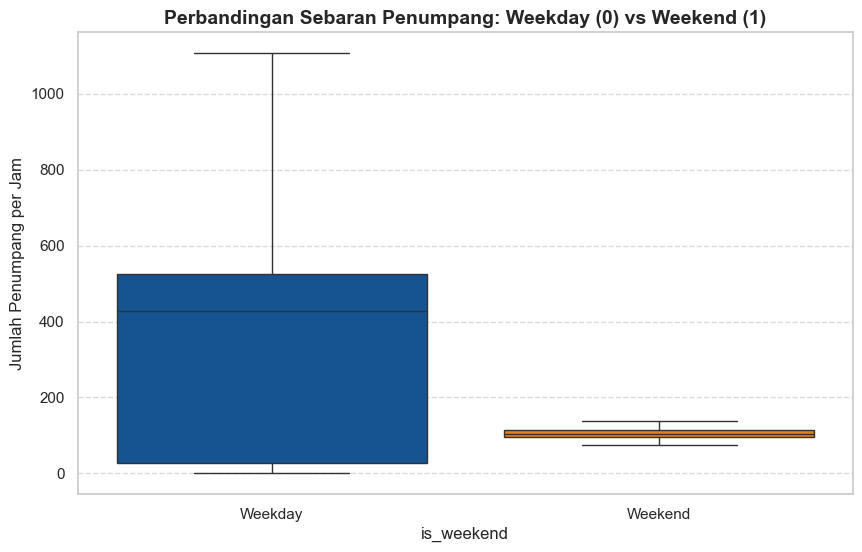

      HASIL UJI T-TEST: WEEKDAY vs WEEKEND
Rata-rata Penumpang/Jam (Weekday): 387.93
Rata-rata Penumpang/Jam (Weekend): 104.76
T-Statistic : 5.0099
P-Value     : 0.0000019500

KESIMPULAN: Tolak H0 (Signifikan)
Terdapat perbedaan beban penumpang yang nyata secara statistik antara
hari kerja dan hari libur.


In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_weekend', y='passenger_count', data=daily_hourly_data, palette=['#0054A6', '#FF8200'])

plt.title('Perbandingan Sebaran Penumpang: Weekday (0) vs Weekend (1)', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Jumlah Penumpang per Jam')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Output Hasil
print("="*50)
print("      HASIL UJI T-TEST: WEEKDAY vs WEEKEND")
print("="*50)
print(f"Rata-rata Penumpang/Jam (Weekday): {weekday_sample.mean():.2f}")
print(f"Rata-rata Penumpang/Jam (Weekend): {weekend_sample.mean():.2f}")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print("\nKESIMPULAN: Tolak H0 (Signifikan)")
    print("Terdapat perbedaan beban penumpang yang nyata secara statistik antara")
    print("hari kerja dan hari libur.")
else:
    print("\nKESIMPULAN: Gagal Tolak H0 (Tidak Signifikan)")
    print("Tidak ditemukan perbedaan beban yang cukup kuat secara statistik.")
print("="*50)

<span style="color:orange">Berdasarkan uji T-Test (p < 0.05), terdapat perbedaan volume penumpang hari libur secara signifikan lebih rendah dan dengan grafik lebih stabil (tanpa puncak tajam). Pada hari libur pengalihan 40-50% armada dari koridor bisnis ke jadwal perawatan rutin pada hari libur sangat disarankan karena tidak mengorbankan kualitas layanan.</span>


## 4. Kesimpulan

* <span style="color:orange"> Beban Penumpang pada jam sibuk jauh lebih tinggi (bisa 2-3 kali lipat) dibandingkan pada jam sepi. Ini adalah bukti kuat bahwa armada harus terkonsentrasi di jam-jam tersebut.

* <span style="color:orange"> Durasi Perjalanan di jam sibuk jauh lebih tinggi, itu menunjukkan adanya kemacetan parah yang menghambat sirkulasi bus (headway), 


* <span style="color:orange"> Sinkronisasi Feeder dan BRT sudah berjalan baik.</span>

* <span style="color:orange"> Proporsi layanan dari Feeder tidak sebanding dengan proporsi dari BRT</span>

* <span style="color:orange">Beban operasional Transjakarta tidak hanya terjadi di jalan raya, tetapi terkonsentrasi di halte-halte transit tertentu.</span>

* <span style="color:orange"> Pada waktu weekend: Pola cenderung landai di pagi hari dan baru mulai meningkat secara stabil setelah jam 10:00 pagi. Tidak ada lonjakan drastis, melainkan penyebaran penumpang yang merata hingga malam hari.</span>
* <span style="color:orange"> Kebutuhan armada hari libur tidak dipicu oleh jam masuk kantor, melainkan jam rekreasi masyarakat yang lebih fleksibel.</span>


## 5. Rekomedasi
* <span style="color:orange"> Pelaksanaan strategi penjadwalan yang dinamis pada jam sibuk dan jam sepi perlu sangat diperlukan untuk efektifitas dan kenyamanan Transjakarta</span>
* <span style="color:orange"> Penambahan bus cadangan di titik transit sangat diperlukan untuk mengurangi kemacetan parah yang menghambat sirkulasi bus.</span>
* <span style="color:orange"> PT Transjakarta secara aman dapat menarik sebagian armada untuk perawatan rutin di jam 11.00-14.00 tanpa mengurangi kualitas layanan bagi penumpang siang hari sehingga tetap dapat beroperasi maksimal pada saat jam sibuk.</span>
* <span style="color:orange"> Perlunya penambahan proporsi armada feeder agar sebanding dengan BRT sehingga kapasitas penumpang menjadi lebih maksimal.</span>
* <span style="color:orange"> Mengoptimalkan 5 halte transit dengan kepadatan teratas akan berdampak signifikan pada efisiensi sistem secara keseluruhan.</span>
* <span style="color:orange"> Pada Weekend, dapat diterapkan Steady-Flow (jumlah bus konsisten dari siang hingga malam) namun dengan total kapasitas yang lebih rendah (sekitar 40-60% dari kapasitas hari kerja).</span>
* <span style="color:orange">Pada hari libur pengalihan 40-50% armada dari koridor bisnis ke jadwal perawatan rutin pada hari libur sangat disarankan karena tidak mengorbankan kualitas layanan.</span>
* <span style="color:orange"> Mengurangi frekuensi bus di koridor perkantoran pada waktu libur untuk dialihkan ke koridor wisata agar waktu tunggu di tempat rekreasi tidak terlalu lama bagi warga yang berlibur.</span>
